# Exploratory Data Analysis (EDA) - US Traffic Incident Analysis
สรุป Insight สำคัญที่ส่งผลต่อความรุนแรง (Severity) และระยะเวลาของอุบัติเหตุ (Duration) เพื่อนำไปใช้ในการทำ Feature Engineering และเลือก Model

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting format
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

In [7]:
df = pd.read_csv("../data/processed/01.3/train_advance_clean.csv")
print(f"Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Data loaded: 5,469,092 rows, 40 columns


,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,...,Traffic_Signal,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Duration(min),Start_Date,Hour,Month,Weather_Group
0,3,2016-11-08 08:50:37,29.718655,-95.321053,0.010,Accident on I-45 Northbound at I-45 Exits 43A ...,I-45 N,Houston,Harris,TX,...,True,Day,Day,Day,Day,29.116667,2016-11-08,8,11,Cloudy
1,2,2021-07-26 07:04:56,38.927551,-121.080093,0.000,Right hand shoulder blocked due to accident on...,Taylor Ln,Auburn,Placer,CA,...,False,Day,Day,Day,Day,46.600000,2021-07-26,7,7,Clear
2,2,2018-10-24 08:23:38,34.776241,-86.672829,0.000,Lane blocked due to accident on AL-255 Researc...,Highway 255,Huntsville,Madison,AL,...,False,Day,Day,Day,Day,29.650000,2018-10-24,8,10,Clear
3,3,2019-07-11 10:42:48,42.384880,-83.149467,0.600,Entry ramp to I-96 Westbound from Davison West...,Edward J Jeffries Fwy,Detroit,Wayne,MI,...,False,Day,Day,Day,Day,118.650000,2019-07-11,10,7,Clear
4,2,2020-11-06 01:29:00,33.776575,-117.837134,0.474,1023: NB 55 JNO 22. SV REAR ENDED VV AND WAS L...,Garden Grove Fwy,Orange,Orange,CA,...,False,Night,Night,Night,Night,140.533333,2020-11-06,1,11,Clear


## 1. Target Relationship: Severity vs Duration
ดูว่าระดับความรุนแรงของอุบัติเหตุส่งผลต่อระยะเวลาที่รถติด (Duration) อย่างไร

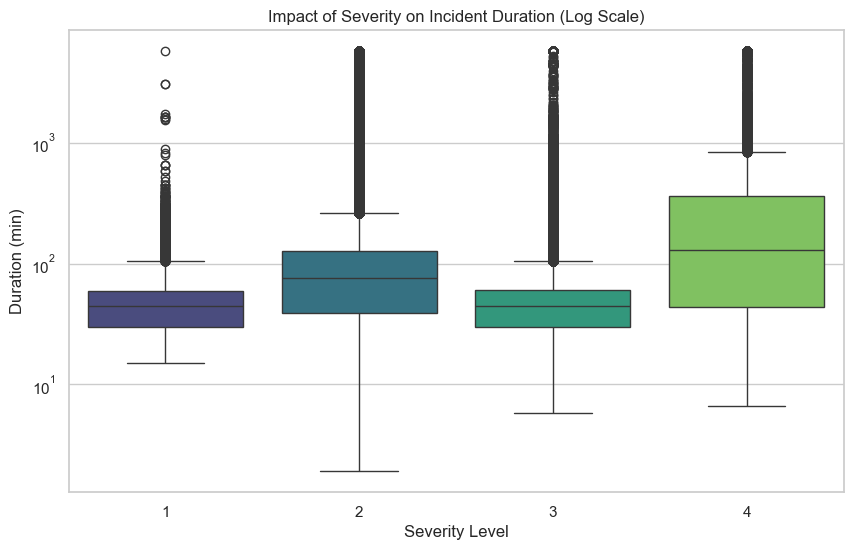

Median Duration by Severity:
Severity
1     44.750000
2     75.600000
3     44.400000
4    130.433333
Name: Duration(min), dtype: float64


In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Severity', y='Duration(min)', palette='viridis')
plt.yscale('log') # ใช้ log scale เพื่อให้เห็นความต่างชัดเจนขึ้นเนื่องจากมี outlier
plt.title('Impact of Severity on Incident Duration (Log Scale)')
plt.xlabel('Severity Level')
plt.ylabel('Duration (min)')
plt.show()

print("Median Duration by Severity:")
print(df.groupby('Severity')['Duration(min)'].median())

## 2. Temporal Analysis: Rush Hour & Day/Night Effects
วิเคราะห์แนวโน้มอุบัติเหตุตามช่วงเวลาเร่งด่วน และความแตกต่างระหว่างกลางวัน/กลางคืน

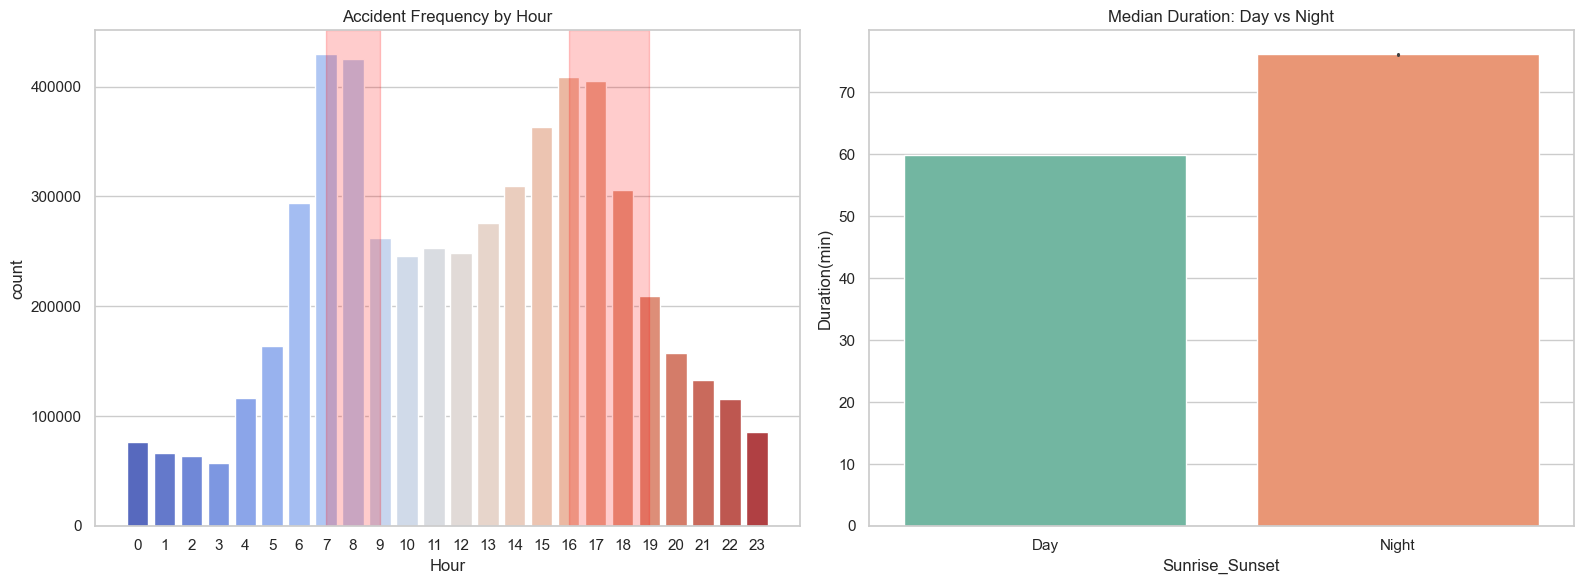

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hourly Count
sns.countplot(data=df, x='Hour', ax=axes[0], palette='coolwarm')
axes[0].axvspan(7, 9, alpha=0.2, color='red', label='Morning Rush')
axes[0].axvspan(16, 19, alpha=0.2, color='red', label='Evening Rush')
axes[0].set_title('Accident Frequency by Hour')

# Sunrise_Sunset vs Duration
sns.barplot(data=df, x='Sunrise_Sunset', y='Duration(min)', ax=axes[1], estimator=np.median, palette='Set2')
axes[1].set_title('Median Duration: Day vs Night')

plt.tight_layout()
plt.show()

## 3. Weather Impact
สภาพอากาศกลุ่มไหนที่ทำให้ระยะเวลาจัดการอุบัติเหตุนานที่สุด

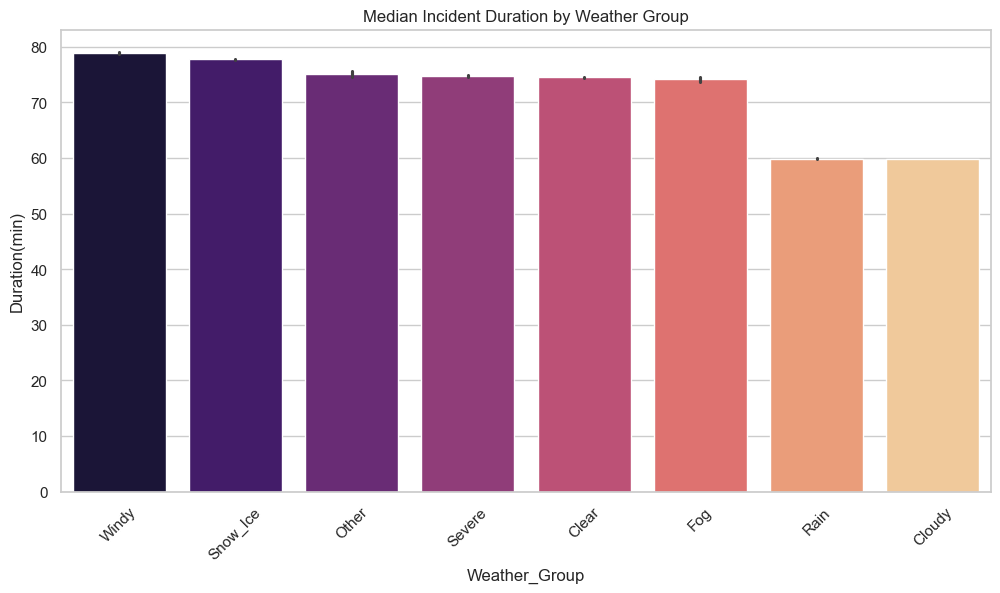

In [10]:
weather_order = df.groupby('Weather_Group')['Duration(min)'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Weather_Group', y='Duration(min)', order=weather_order, estimator=np.median, palette='magma')
plt.title('Median Incident Duration by Weather Group')
plt.xticks(rotation=45)
plt.show()

## 4. Road Feature Influence
ลักษณะทางกายภาพของถนนจุดไหนที่ส่งผลต่อระยะเวลาจัดการเหตุการณ์

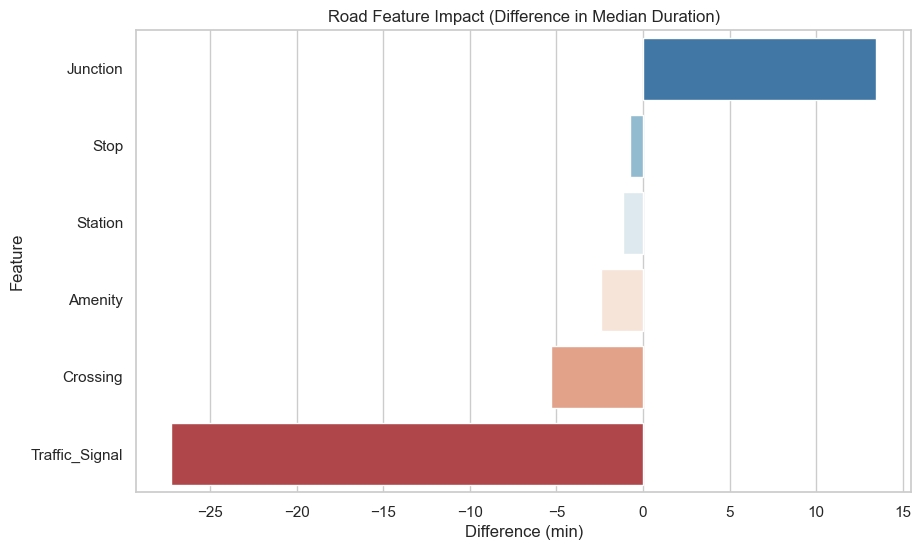

In [11]:
road_features = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Amenity']
impact = []

for feat in road_features:
    true_med = df[df[feat] == True]['Duration(min)'].median()
    false_med = df[df[feat] == False]['Duration(min)'].median()
    impact.append({'Feature': feat, 'Diff': true_med - false_med})

impact_df = pd.DataFrame(impact).sort_values('Diff', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=impact_df, x='Diff', y='Feature', palette='RdBu_r')
plt.title('Road Feature Impact (Difference in Median Duration)')
plt.xlabel('Difference (min)')
plt.show()

## 5. Correlation Heatmap
ตรวจสอบความสัมพันธ์ระหว่างตัวแปรเชิงตัวเลข

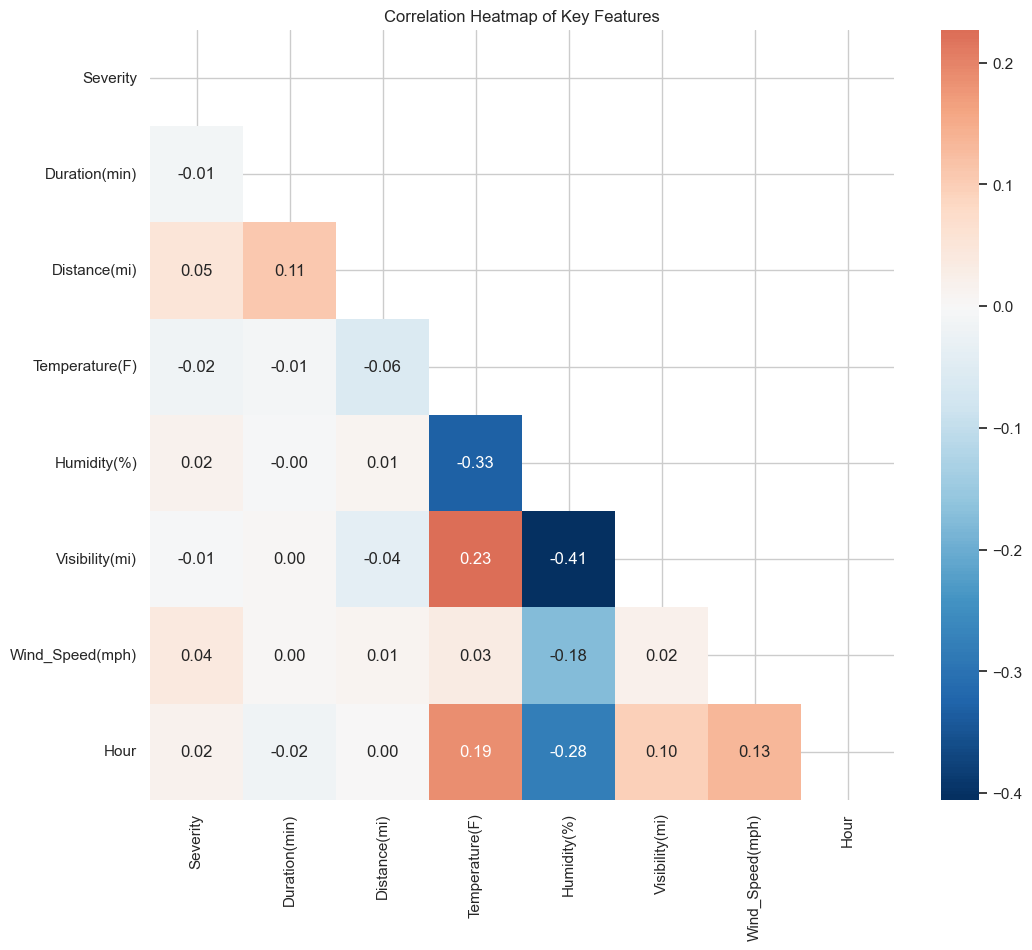

In [12]:
num_cols = ['Severity', 'Duration(min)', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Hour']
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Key Features')
plt.show()

### สรุป Insight สำหรับการทำ Model:
1. **Severity 4** ส่งผลให้ Duration นานกว่าระดับอื่นอย่างชัดเจน
2. **Rush Hour** (เช้าและเย็น) มีอุบัติเหตุหนาแน่นที่สุด แต่ช่วง **กลางคืน** มักใช้เวลาจัดการเหตุนานกว่า
3. สภาพอากาศกลุ่ม **Fog, Severe, Snow_Ice** ส่งผลลบต่อ Duration อย่างมาก
4. จุดที่เป็น **Junction** มีผลกระทบต่อระยะเวลารถติดมากกว่าจุดที่เป็น Traffic Signal
5. ควรทำ Feature Engineering เพิ่มเติม เช่น `Is_Rush_Hour`, `Is_Bad_Weather`, และ `Road_Complexity`